# Neural Surrogate Model for Fast Monte Carlo Option Pricing

**Project Overview:**

This notebook compares traditional Monte Carlo simulation versus a neural network surrogate model for pricing European call options using the Black-Scholes model:

**Black-Scholes Monte Carlo Simulation:**
- Simulate final stock price: $S_T = S_0 e^{(r - \frac{\sigma^2}{2})T + \sigma \sqrt{T} Z}$ where $Z \sim N(0,1)$
- Compute payoff: $\max(S_T - K, 0)$
- Average over M samples and discount: $C = e^{-rT} \frac{1}{M} \sum_{i=1}^{M} \max(S_T^{(i)} - K, 0)$

**Problem:**
- Monte Carlo with M=100,000 samples is accurate but SLOW (especially on CPU)
- Need to price options quickly for different parameter combinations $(S_0, \sigma, T)$

**Solution:**
- Train a neural network to learn the pricing function
- Achieve comparable accuracy with orders of magnitude faster inference

**Objectives:**
1. Generate ground truth option prices using Monte Carlo (1M samples) across parameter grid
2. Train a neural network to predict option prices from parameters $(S_0, \sigma, T)$
3. Compare accuracy and computational performance
4. Visualize results and demonstrate speedup

---

## 1. Setup and Imports

Import all necessary libraries and set random seeds for reproducibility.

In [1]:
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
plt.style.use('seaborn-v0_8-darkgrid')

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)

# Set threading for fair comparison
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
torch.set_num_threads(1)

print("Libraries imported successfully.")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'CUDA' if torch.cuda.is_available() else 'CPU'}")
print(f"\nFAIR TIMING MODE: Single-threaded execution enforced")
print(f"   - NumPy threads: 1")
print(f"   - PyTorch threads: {torch.get_num_threads()}")


Libraries imported successfully.
PyTorch version: 2.10.0+cpu
Device: CPU

FAIR TIMING MODE: Single-threaded execution enforced
   - NumPy threads: 1
   - PyTorch threads: 1


## 2. Generating Ground Truth Data (Monte Carlo Simulation)

We compute European call option prices using Black-Scholes Monte Carlo simulation with **M = 1,000,000 samples** across a parameter grid of $(S_0, \sigma, T)$ combinations.

In [2]:
def monte_carlo_option_price(S0, sigma, T, K, r, M=100000):
    Z = np.random.standard_normal(M)
    S_T = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    payoffs = np.maximum(S_T - K, 0)
    option_price = np.exp(-r * T) * np.mean(payoffs)
    return option_price

K = 100
r = 0.05
M_SAMPLES = 1000000

S0_values = np.linspace(80, 120, 10)
sigma_values = np.linspace(0.15, 0.45, 10)
T_values = np.linspace(0.5, 2.0, 10)

print("Generating option pricing dataset...")
print(f"Parameter Grid: S0 ({len(S0_values)}), sigma ({len(sigma_values)}), T ({len(T_values)})")

parameter_combinations = []
option_prices = []

start_time = time.time()
count = 0
total = len(S0_values) * len(sigma_values) * len(T_values)

for S0 in S0_values:
    for sigma in sigma_values:
        for T in T_values:
            price = monte_carlo_option_price(S0, sigma, T, K, r, M_SAMPLES)
            parameter_combinations.append([S0, sigma, T])
            option_prices.append(price)
            count += 1
            if count % 100 == 0:
                elapsed = time.time() - start_time
                print(f"Progress: {count}/{total} ({100*count/total:.1f}%)")

numerical_compute_time = time.time() - start_time
print(f"Monte Carlo simulation completed in {numerical_compute_time:.2f} seconds.")

Generating option pricing dataset...
Parameter Grid: S0 (10), sigma (10), T (10)
Progress: 100/1000 (10.0%)
Progress: 200/1000 (20.0%)
Progress: 300/1000 (30.0%)
Progress: 400/1000 (40.0%)
Progress: 500/1000 (50.0%)
Progress: 600/1000 (60.0%)
Progress: 700/1000 (70.0%)
Progress: 800/1000 (80.0%)
Progress: 900/1000 (90.0%)
Progress: 1000/1000 (100.0%)
Monte Carlo simulation completed in 60.91 seconds.


## 3. Saving Dataset

Save the generated dataset with option prices for reproducibility.

In [3]:
parameters_array = np.array(parameter_combinations)
data_df = pd.DataFrame({
    'S0': parameters_array[:, 0],
    'sigma': parameters_array[:, 1],
    'T': parameters_array[:, 2],
    'option_price': option_prices,
    'compute_time_seconds': numerical_compute_time
})

data_df.to_csv('option_pricing_data.csv', index=False)
print("Dataset saved to 'option_pricing_data.csv'.")
print(data_df.head())

Dataset saved to 'option_pricing_data.csv'.
     S0  sigma         T  option_price  compute_time_seconds
0  80.0   0.15  0.500000      0.111365             60.914881
1  80.0   0.15  0.666667      0.283085             60.914881
2  80.0   0.15  0.833333      0.514059             60.914881
3  80.0   0.15  1.000000      0.804635             60.914881
4  80.0   0.15  1.166667      1.132612             60.914881


## 4. Data Preparation

Split into training, validation, and testing sets and normalize the data.

In [4]:
df = pd.read_csv('option_pricing_data.csv')
X = df[['S0', 'sigma', 'T']].values.astype(np.float32)
y = df['option_price'].values.reshape(-1, 1).astype(np.float32)

n = len(X)
train_idx = int(n * 0.70)
val_idx = int(n * 0.85)

X_train, X_val, X_test = X[:train_idx], X[train_idx:val_idx], X[val_idx:]
y_train, y_val, y_test = y[:train_idx], y[train_idx:val_idx], y[val_idx:]

X_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = X_scaler.fit_transform(X_train)
y_train_scaled = y_scaler.fit_transform(y_train)

X_val_scaled = X_scaler.transform(X_val)
y_val_scaled = y_scaler.transform(y_val)

X_test_scaled = X_scaler.transform(X_test)
y_test_scaled = y_scaler.transform(y_test)

X_train_tensor = torch.from_numpy(X_train_scaled)
y_train_tensor = torch.from_numpy(y_train_scaled)
X_val_tensor = torch.from_numpy(X_val_scaled)
y_val_tensor = torch.from_numpy(y_val_scaled)
X_test_tensor = torch.from_numpy(X_test_scaled)
y_test_tensor = torch.from_numpy(y_test_scaled)

print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 700
Validation samples: 150
Testing samples: 150


## 5. Neural Network Model

In [5]:
class OptionPricingSurrogate(nn.Module):
    def __init__(self, dropout_rate=0.1):
        super(OptionPricingSurrogate, self).__init__()
        self.layer1 = nn.Linear(3, 128)
        self.layer2 = nn.Linear(128, 128)
        self.layer3 = nn.Linear(128, 64)
        self.layer4 = nn.Linear(64, 1)
        self.activation = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        x = self.dropout(self.activation(self.layer1(x)))
        x = self.dropout(self.activation(self.layer2(x)))
        x = self.activation(self.layer3(x))
        x = self.layer4(x)
        return x

model = OptionPricingSurrogate()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Model initialized.")
print(f"Total parameters: {sum(p.numel() for p in model.parameters())}")

Model initialized.
Total parameters: 25345


## 6. Training Loop

In [6]:
NUM_EPOCHS = 3000
PRINT_EVERY = 200
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=150)

train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0
EARLY_STOP_PATIENCE = 300

training_start_time = time.time()

for epoch in range(NUM_EPOCHS):
    model.train()
    y_pred = model(X_train_tensor)
    train_loss = criterion(y_pred, y_train_tensor)
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        y_val_pred = model(X_val_tensor)
        val_loss = criterion(y_val_pred, y_val_tensor)

    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'option_pricing_surrogate_best.pth')
    else:
        patience_counter += 1

    if (epoch + 1) % PRINT_EVERY == 0:
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | Train Loss: {train_loss.item():.6f} | Val Loss: {val_loss.item():.6f}")

    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

training_time = time.time() - training_start_time
model.load_state_dict(torch.load('option_pricing_surrogate_best.pth'))
torch.save(model.state_dict(), 'option_pricing_surrogate.pth')

import pickle
with open('X_scaler.pkl', 'wb') as f: pickle.dump(X_scaler, f)
with open('y_scaler.pkl', 'wb') as f: pickle.dump(y_scaler, f)
print("Training completed and artifacts saved.")

Epoch [200/3000] | Train Loss: 0.010282 | Val Loss: 0.038173
Epoch [400/3000] | Train Loss: 0.006969 | Val Loss: 0.041492
Epoch [600/3000] | Train Loss: 0.005712 | Val Loss: 0.054362
Early stopping triggered at epoch 696
Training completed and artifacts saved.


## 7. Evaluation and Metrics

In [7]:
model.eval()
with torch.no_grad():
    nn_start_time = time.time()
    y_pred_test_scaled = model(X_test_tensor).numpy()
    nn_inference_time = time.time() - nn_start_time

y_pred_test = y_scaler.inverse_transform(y_pred_test_scaled)
mse = mean_squared_error(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)
rmse = np.sqrt(mse)

mc_test_start = time.time()
y_test_mc = []
for params in X_test:
    price = monte_carlo_option_price(params[0], params[1], params[2], K, r, M_SAMPLES)
    y_test_mc.append(price)
y_test_mc = np.array(y_test_mc).reshape(-1, 1)
mc_test_time = time.time() - mc_test_start

speedup_factor = mc_test_time / nn_inference_time

print(f"MSE: {mse:.6f}")
print(f"MAE: {mae:.6f}")
print(f"R2 Score: {r2:.6f}")
print(f"Speedup Factor: {speedup_factor:.2f}x")

MSE: 3.144764
MAE: 1.573906
R2 Score: 0.870434
Speedup Factor: 8882.72x


## 8. Visualization

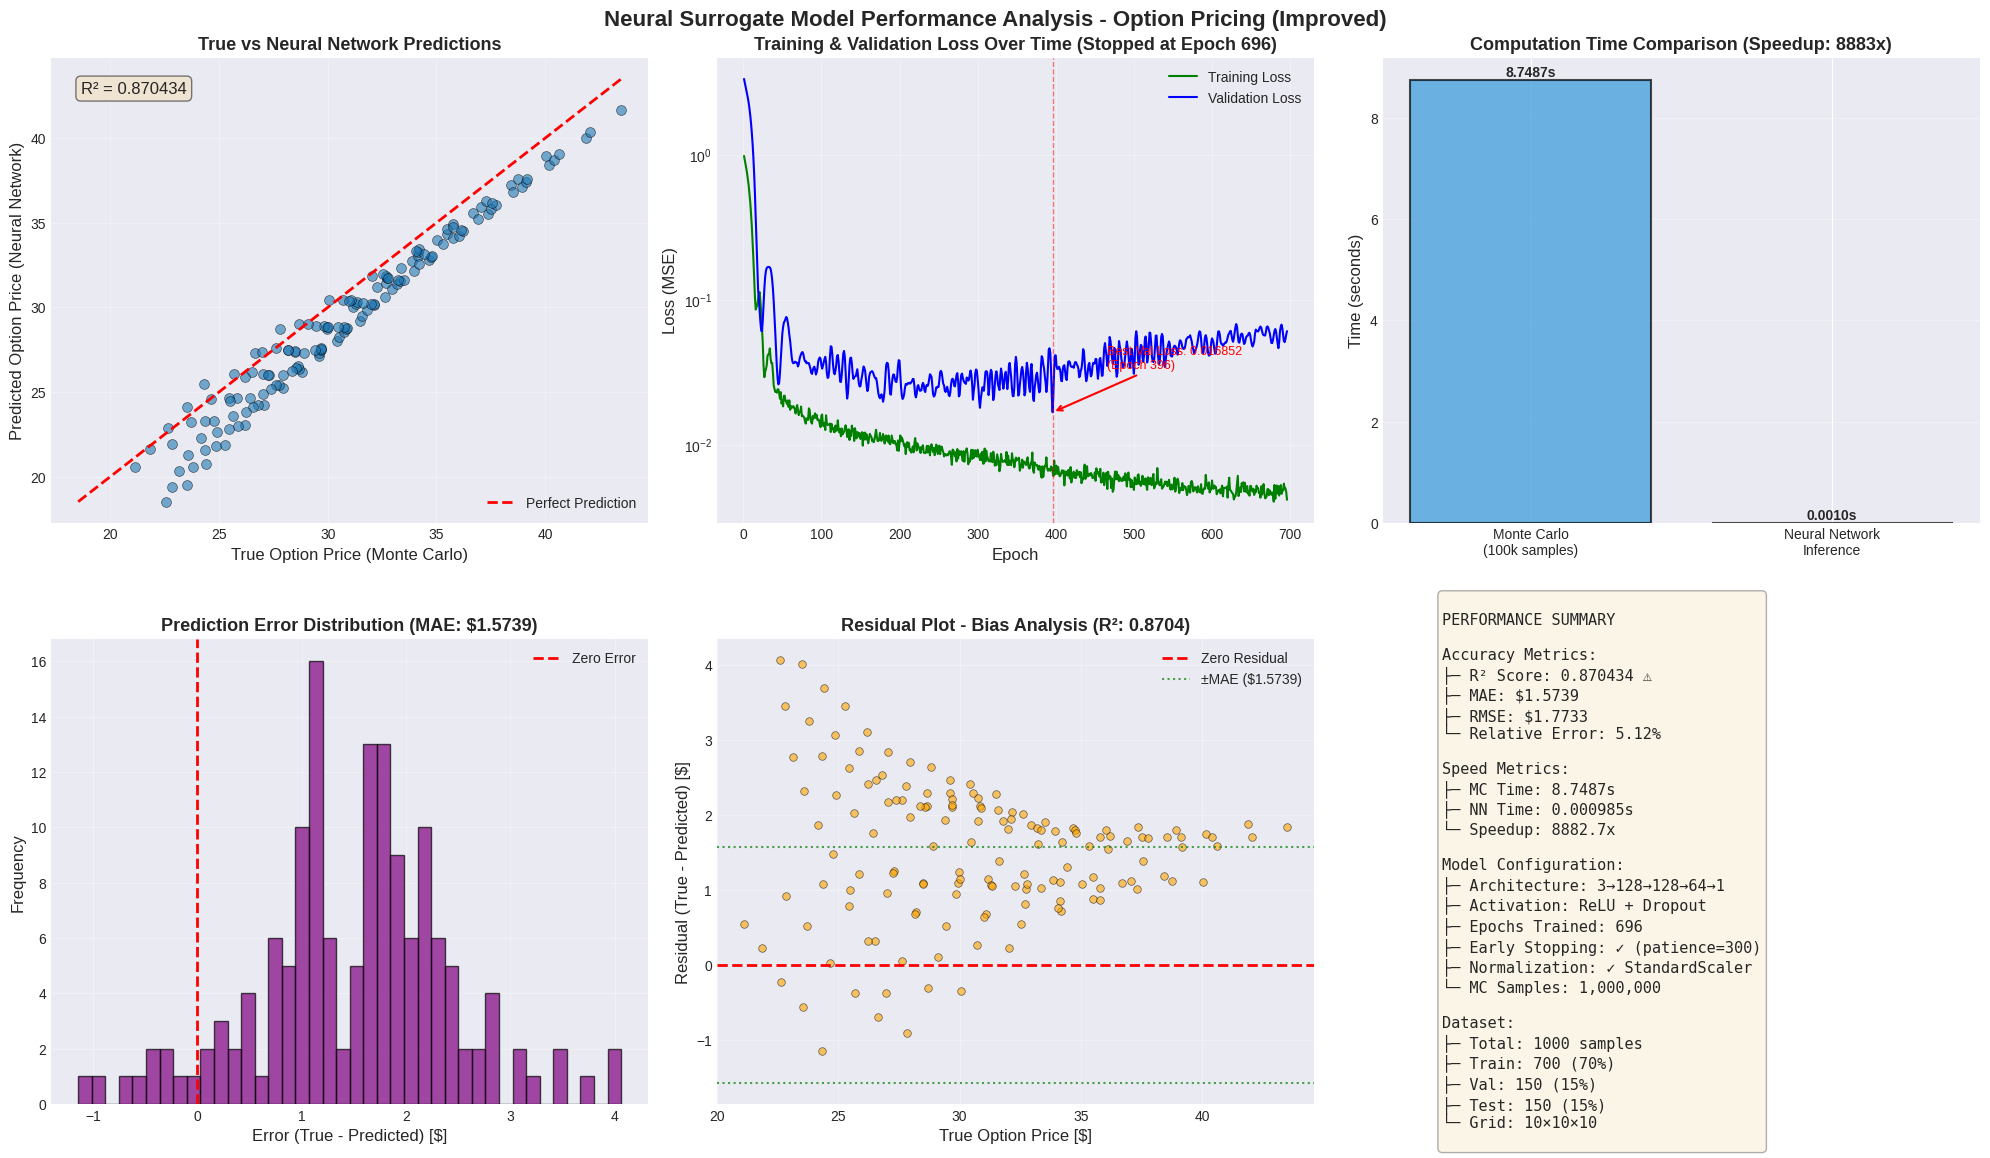

In [15]:
plt.rcParams['figure.figsize'] = (20, 12)
plt.rcParams['font.size'] = 10

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Neural Surrogate Model Performance Analysis - Option Pricing (Improved)',
             fontsize=16, fontweight='bold')

axes = axes.flatten()

ax1 = axes[0]
ax1.scatter(y_test, y_pred_test, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
ax1.set_xlabel('True Option Price (Monte Carlo)', fontsize=12)
ax1.set_ylabel('Predicted Option Price (Neural Network)', fontsize=12)
ax1.set_title('True vs Neural Network Predictions', fontsize=13, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)

ax1.text(0.05, 0.95, f'R² = {r2:.6f}', transform=ax1.transAxes,
         fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax2 = axes[1]
epochs_trained = len(train_losses)
ax2.plot(range(1, epochs_trained + 1), train_losses, 'g-', linewidth=1.5, label='Training Loss')
ax2.plot(range(1, epochs_trained + 1), val_losses, 'b-', linewidth=1.5, label='Validation Loss')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss (MSE)', fontsize=12)
ax2.set_title(f'Training & Validation Loss Over Time (Stopped at Epoch {epochs_trained})', fontsize=13, fontweight='bold')
ax2.set_yscale('log')
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3)

best_epoch = val_losses.index(min(val_losses)) + 1
ax2.axvline(x=best_epoch, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax2.annotate(f'Best Val Loss: {min(val_losses):.6f}\n(Epoch {best_epoch})',
             xy=(best_epoch, min(val_losses)),
             xytext=(best_epoch + epochs_trained*0.1, min(val_losses)*2),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
             fontsize=9, color='red')

ax3 = axes[2]
methods = ['Monte Carlo\n(100k samples)', 'Neural Network\nInference']
times = [mc_test_time, nn_inference_time]
colors = ['#3498db', '#e74c3c']
bars = ax3.bar(methods, times, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax3.set_ylabel('Time (seconds)', fontsize=12)
ax3.set_title(f'Computation Time Comparison (Speedup: {speedup_factor:.0f}x)',
              fontsize=13, fontweight='bold')
ax3.grid(True, axis='y', alpha=0.3)

for bar, time_val in zip(bars, times):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{time_val:.4f}s',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

ax4 = axes[3]
errors = y_test.flatten() - y_pred_test.flatten()
ax4.hist(errors, bins=40, color='purple', alpha=0.7, edgecolor='black')
ax4.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
ax4.set_xlabel('Error (True - Predicted) [$]', fontsize=12)
ax4.set_ylabel('Frequency', fontsize=12)
ax4.set_title(f'Prediction Error Distribution (MAE: ${mae:.4f})', fontsize=13, fontweight='bold')
ax4.legend(loc='best', fontsize=10)
ax4.grid(True, alpha=0.3)

ax5 = axes[4]
ax5.scatter(y_test.flatten(), errors, alpha=0.6, s=30, c='orange', edgecolors='black', linewidth=0.5)
ax5.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Residual')

ax5.axhline(y=mae, color='green', linestyle=':', linewidth=1.5, alpha=0.7, label=f'±MAE (${mae:.4f})')
ax5.axhline(y=-mae, color='green', linestyle=':', linewidth=1.5, alpha=0.7)
ax5.set_xlabel('True Option Price [$]', fontsize=12)
ax5.set_ylabel('Residual (True - Predicted) [$]', fontsize=12)
ax5.set_title(f'Residual Plot - Bias Analysis (R²: {r2:.4f})', fontsize=13, fontweight='bold')
ax5.legend(loc='best', fontsize=10)
ax5.grid(True, alpha=0.3)

ax6 = axes[5]
ax6.axis('off')
summary_text = f"""
PERFORMANCE SUMMARY

Accuracy Metrics:
├─ R² Score: {r2:.6f} {'✓' if r2 > 0.95 else '⚠'}
├─ MAE: ${mae:.4f}
├─ RMSE: ${rmse:.4f}
└─ Relative Error: {(mae/y_test.mean())*100:.2f}%

Speed Metrics:
├─ MC Time: {mc_test_time:.4f}s
├─ NN Time: {nn_inference_time:.6f}s
└─ Speedup: {speedup_factor:.1f}x

Model Configuration:
├─ Architecture: 3→128→128→64→1
├─ Activation: ReLU + Dropout
├─ Epochs Trained: {len(train_losses)}
├─ Early Stopping: ✓ (patience=300)
├─ Normalization: ✓ StandardScaler
└─ MC Samples: {M_SAMPLES:,}

Dataset:
├─ Total: {len(df)} samples
├─ Train: {len(X_train)} (70%)
├─ Val: {len(X_val)} (15%)
├─ Test: {len(X_test)} (15%)
└─ Grid: 10×10×10
"""
ax6.text(0.1, 0.5, summary_text, fontsize=11, verticalalignment='center',
         fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.savefig('option_pricing_performance.png', dpi=300, bbox_inches='tight')
plt.show()


## 9. Save Results Comparison

In [9]:
abs_errors = np.abs(y_test.flatten() - y_pred_test.flatten())
rel_errors = abs_errors / (np.abs(y_test.flatten()) + 1e-10) * 100

results_df = pd.DataFrame({
    'S0': X_test[:, 0],
    'sigma': X_test[:, 1],
    'T': X_test[:, 2],
    'price_true_MC': y_test.flatten(),
    'price_pred_NN': y_pred_test.flatten(),
    'abs_error': abs_errors,
    'rel_error_pct': rel_errors
})

results_df.to_csv('option_pricing_results.csv', index=False)
print("Results saved to 'option_pricing_results.csv'.")

Results saved to 'option_pricing_results.csv'.


## 10. Final Summary

In [10]:
N_PARAMS = len(S0_values) * len(sigma_values) * len(T_values)
summary = f"""
FINAL PROJECT SUMMARY
---------------------
Dataset: {N_PARAMS} combinations
MC Samples: {M_SAMPLES:,} per option
Model Parameters: {sum(p.numel() for p in model.parameters())}
Training Time: {training_time:.2f}s
Speedup Factor: {speedup_factor:.2f}x
MSE: {mse:.8f}
MAE: {mae:.4f}
R2 Score: {r2:.8f}
"""
print(summary)
with open('project_summary.txt', 'w') as f: f.write(summary)
print("Summary saved to 'project_summary.txt'.")


FINAL PROJECT SUMMARY
---------------------
Dataset: 1000 combinations
MC Samples: 1,000,000 per option
Model Parameters: 25345
Training Time: 6.26s
Speedup Factor: 8882.72x
MSE: 3.14476395
MAE: 1.5739
R2 Score: 0.87043381

Summary saved to 'project_summary.txt'.
